In [1]:
import numpy as np
import math
import time
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import glob

from utils import training_curve_plot
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision.utils import make_grid
from torchvision.transforms import v2 as T
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader


In [2]:
np.random.seed(777)

### Data Loading

In [118]:
from torchvision.io import decode_image

class WarwickDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        size = len([f for f in glob.glob(f'{self.img_dir}/image_*.png', recursive=False)])
        return size

    def __getitem__(self, idx):
        idx_shifted = idx+1
        idx_str = str(idx_shifted) if idx_shifted>9 else f"0{idx_shifted}"

        image = decode_image(os.path.join(self.img_dir, f"image_{idx_str}.png"))/255.0
        label = decode_image(os.path.join(self.img_dir, f"label_{idx_str}.png"))/255.0
        
        if self.transform:
            image = self.transform(image)


        sample = {'image': image, 'label': label}    

        return sample

In [119]:
path = 'WARWICK/Train'
size = len([f for f in glob.glob(f'{path}/image_*.png', recursive=False)])
size

85

In [120]:
train_data = WarwickDataset(img_dir='WARWICK/Train')
test_data = WarwickDataset(img_dir='WARWICK/Test')

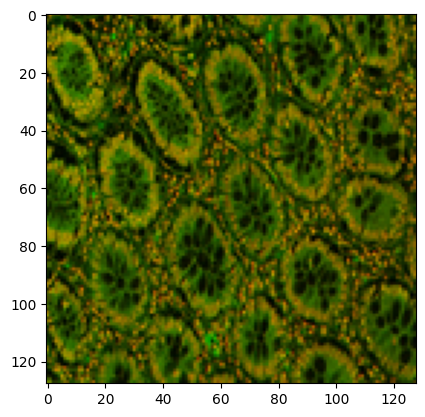

In [121]:
sample_1 = train_data[8]["image"].permute(1, 2, 0)
#sample_1
plt.imshow(sample_1)
plt.show()

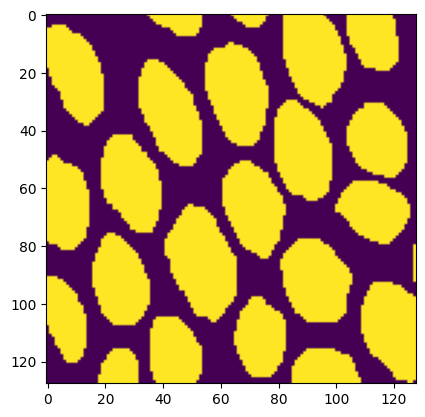

In [122]:
lab_1 = train_data[8]["label"].permute(1, 2, 0)
#sample_1
plt.imshow(lab_1)
plt.show()

In [123]:
print(lab_1.unique())

tensor([0., 1.])


In [124]:
train_dataloader = DataLoader(train_data, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=16, shuffle=True)

In [125]:
len(train_dataloader)

6

In [51]:
for batch in train_dataloader:
    x = batch["image"]
    y = batch["label"]
    print(x.shape)
    print(y.shape)
    print("**"*10)

torch.Size([16, 3, 128, 128])
torch.Size([16, 1, 128, 128])
********************
torch.Size([16, 3, 128, 128])
torch.Size([16, 1, 128, 128])
********************
torch.Size([16, 3, 128, 128])
torch.Size([16, 1, 128, 128])
********************
torch.Size([16, 3, 128, 128])
torch.Size([16, 1, 128, 128])
********************
torch.Size([16, 3, 128, 128])
torch.Size([16, 1, 128, 128])
********************
torch.Size([5, 3, 128, 128])
torch.Size([5, 1, 128, 128])
********************


In [39]:
# extract a complete PyTorch dataset
def extract(dataset):
    datasize = len(dataset)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=datasize, shuffle=False)
    return next(iter(dataloader))

In [40]:
print("Use GPU: ", torch.cuda.is_available())

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

Use GPU:  False


### Training Functions

In [22]:
def predict(net, X):
    return net(X).argmax(dim=1)

def accuracy(G, Y):
    return (G.argmax(dim=1) == Y.argmax(dim=1)).float().mean()

In [126]:
class TrainedModel:
    def __init__(self,model, train_acc, test_acc, train_cost, test_cost, elapsed, epochs, batch_size, lr):
        self.model = model
        self.train_acc = train_acc
        self.test_acc = test_acc
        self.train_cost = train_cost
        self.test_cost = test_cost
        self.elapsed = elapsed
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr


    def plot_loss_cost(self,title):
        
        training_curve_plot(title,
                        self.train_cost, 
                        self.test_cost, 
                        self.train_acc, 
                        self.test_acc,
                        self.batch_size, 
                        self.lr, 
                        self.epochs, 
                        self.elapsed)
        return 0
    
    
    def plot_predictions(self, testset, n):

        # evaluate the network on 100 random test images
        with torch.no_grad():
            # obtain 100 random samples from the test data set
            random_X, random_Y = next(iter(torch.utils.data.DataLoader(testset, batch_size=n, shuffle=True)))

            # move data to the GPU if needed
            random_X, random_Y = random_X.to(device), random_Y.to(device)

            # compute the predictions for the sampled inputs
            random_Yhat = predict(self.model, random_X)

            # sort the predictions with the incorrect ones first
            indices_incorrect_first = (random_Yhat == random_Y.argmax(dim=1)).float().argsort()

        # plot the images
        num_rows = 10
        num_cols = 10
        num_images = num_rows * num_cols
        plt.figure(figsize=(num_cols, num_rows))

        for i, index in enumerate(indices_incorrect_first, 1):
            plt.subplot(num_rows, num_cols, i)
            plt.xticks([])
            plt.yticks([])

            # plot the image
            plt.imshow(random_X[index, :].view(28, 28).cpu().numpy(), cmap=plt.cm.binary)

            # add the prediction as annotation (incorrect predictions in red, correct ones in blue)
            color = 'blue' if random_Yhat[index] == random_Y[index].argmax() else 'red'
            plt.text(0, 25, random_Yhat[index].item(), fontsize=25, color=color)

        plt.show()


    def plot_confusion_matrix(self, testset):

        with torch.no_grad():
            test_X, test_Y = extract(testset)
            y_preds = predict(self.model, test_X.to(device)).cpu().numpy()
            y_labels = test_Y.to(device).cpu().numpy()

        class_names = np.arange(10) # for MNIST labels
        cm = confusion_matrix(y_labels.argmax(1), y_preds).astype(np.float64)

        plt.figure(figsize=(6, 6))
        plt.imshow(cm, interpolation='nearest', cmap='viridis')
        plt.title("Confusion Matrix")
        plt.colorbar(shrink=0.75, fraction=0.05)

        tick_marks = np.arange(len(class_names))
        plt.xticks(tick_marks, class_names)
        plt.yticks(tick_marks, class_names)

        plt.xlabel("Predicted label")
        plt.ylabel("True label")

        plt.tight_layout()
        plt.show()

In [24]:
def weight_init(net_l):
    # network initialization function
    if not isinstance(net_l, list):
        net_l = [net_l]
    for net in net_l:
        for m in net.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight)
                m.bias.data.fill_(0.0)

In [132]:
def dice_coef(pred, target):
    pred = torch.sigmoid(pred) #convert logits to probabilities

    inter = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    
    dice = (2.0 * inter+ 1e-8) / (union+ 1e-8) #+ 1e-8 for numerical stability

    return dice.mean()

In [158]:
def train_model(model, learning_rate, batch_size, num_epochs, trainset, testset, device='cpu', optimizer = "SGD"):
    # initialize the test and training error statistics
    test_acc = []
    test_cost = []
    test_iter = []
    train_acc = []
    train_cost = []

    # define the data loaders
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, num_workers=2, shuffle=True)
    
    testloader = torch.utils.data.DataLoader(testset, batch_size=len(testset), shuffle=False)
    test_batch = next(iter(testloader))
    test_X = test_batch["image"]
    test_Y = test_batch["label"]


    # initialize the neural network and move it to the GPU if needed
    model.to(device)
    model.train(True)


    # define the loss and optimization algos
    pos_weight = torch.tensor([5.0]).to(device)  # try 5–20
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    if optimizer=="SGD":
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)


    t = 0 # current iteration
    start_time = time.time()

    # Training loop
    for epoch in range(num_epochs):
        print(f"epoch {epoch:2d}")
        for batch in trainloader:

            batch_X = batch["image"].to(device)
            batch_Y = batch["label"].to(device) # move batch to the GPU if needed
            print(f"Sanity check - binary labels: {batch_Y.unique()}")

            optimizer.zero_grad() # reset the gradients back to zero
            out = model(batch_X)
            print(f"Sanity check - shape: {out.shape == batch_Y.shape}")
            print(f"Sanity check - output scale: {out.min().item(), out.max().item()}")
            loss = criterion(out,batch_Y)

            loss.backward()
            optimizer.step() # Adjust learning weights


            # don't bother too much about the following lines!
            # Set the model to evaluation mode, disabling dropout and using population
            # statistics for batch normalization.
            model.eval()

            with torch.no_grad():
                # evaluate the performance on the training data at every 100th iteration
                if t % 10 == 0:
                    train_cost.append(loss.item())
                    train_acc.append(dice_coef(out, batch_Y).item())

                # evaluate the performance on the test data at every 100th iteration
                if t % 10 == 0:
                    # move test data to the GPU if needed
                    X, Y = test_X.to(device), test_Y.to(device)

                    # compute predictions for the test data
                    G = model(X)
                    test_cost.append(criterion(G, Y).item())
                    #test_cost.append(criterion(nn.Sigmoid(G), Y).item())

                    test_acc.append(dice_coef(G, Y).item())
                    test_iter.append(t)

                    # print the iteration number and the accuracy of the predictions
                    print(f"Epoch {epoch:2d} - Step {t:5d}: \n\ttrain dice_coef {100 * train_acc[-1]:6.2f}% " \
                        f"train costs {train_cost[-1]:5.2f}  " \
                        f"\n\ttest dice_coef {100 * test_acc[-1]:6.2f}% " \
                        f"test costs {test_cost[-1]:5.2f}")

            # accumulate iterations
            t += 1
            model.train()

    end_time = time.time()
    elapsed = end_time - start_time

    #return model, train_acc, test_acc, train_cost, test_cost, elapsed
    return TrainedModel(
                    model,
                    train_acc,
                    test_acc,
                    train_cost,
                    test_cost,
                    elapsed,
                    num_epochs,
                    batch_size,
                    learning_rate
                )


In [ ]:

class CNN_Net(nn.Module):
    def __init__(self):
        super(CNN_Net, self).__init__()

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.down1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.down2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.down3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)

        self.up1 = nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=4, stride=2, padding=1)
        self.up2 = nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=4, stride=2, padding=1)
        self.up3 = nn.ConvTranspose2d(in_channels=16, out_channels=1, kernel_size=4, stride=2, padding=1)

        self.resize_conv = nn.Conv2d(16, 1, kernel_size=1)

        # network initialization
        self.apply(weight_init)

    def forward(self, input):
        # get back to image chape 1 x 28 x 28  (first dim = channels, =1 because grayscale)
        #x = torch.reshape(input, (input.shape[0], int(math.sqrt(input.shape[1])), int(math.sqrt(input.shape[1]))))
        #x = torch.unsqueeze(x,dim=1)
   
        x = self.relu(self.down1(input))
        x = self.pool(x)

        x = self.relu(self.down2(x))
        x = self.pool(x)

        x = self.relu(self.down3(x))
        #x = self.pool(x)
        #print(f"Shape after last down: {x.shape}")

        x = self.relu(self.up1(x))
        #print(f"Shape after up1: {x.shape}")

        x = self.relu(self.up2(x))
        #print(f"Shape after up2: {x.shape}")

        x = self.up3(x)
        #print(f"Shape after up3: {x.shape}")

        x = self.resize_conv(x)


        return x

In [136]:
sample_1 = train_data[8]["image"].permute(1, 2, 0)
sample_1


tensor([[[0.2627, 0.2235, 0.0000],
         [0.7490, 0.5216, 0.0000],
         [0.3373, 0.3765, 0.0000],
         ...,
         [0.0745, 0.1412, 0.0000],
         [0.1725, 0.2471, 0.0000],
         [0.2510, 0.3098, 0.0000]],

        [[0.1686, 0.1922, 0.0000],
         [0.3804, 0.3451, 0.0000],
         [0.1098, 0.2745, 0.0000],
         ...,
         [0.0392, 0.1216, 0.0000],
         [0.1490, 0.2196, 0.0000],
         [0.3922, 0.3961, 0.0000]],

        [[0.3373, 0.3412, 0.0000],
         [0.1922, 0.2392, 0.0000],
         [0.0745, 0.1843, 0.0000],
         ...,
         [0.0510, 0.1137, 0.0000],
         [0.1804, 0.2157, 0.0000],
         [0.2784, 0.3020, 0.0000]],

        ...,

        [[0.0980, 0.1294, 0.0000],
         [0.0784, 0.0902, 0.0000],
         [0.0235, 0.0706, 0.0000],
         ...,
         [0.3490, 0.3922, 0.0000],
         [0.3882, 0.4431, 0.0000],
         [0.2549, 0.4431, 0.0000]],

        [[0.2118, 0.3373, 0.0000],
         [0.2549, 0.3216, 0.0000],
         [0.

In [164]:
learning_rate = 0.01
epochs = 20
batch_size = 8

model = CNN_Net()

model_base = train_model(model,
                        learning_rate,
                        batch_size,
                        epochs,
                        train_data,
                        test_data,
                        device='cpu')


epoch  0
Sanity check - binary labels: tensor([0., 1.])
Sanity check - shape: False
Sanity check - output scale: (-0.03376297280192375, 0.07792700827121735)


ValueError: Target size (torch.Size([8, 1, 128, 128])) must be the same as input size (torch.Size([8, 1, 248, 248]))

0

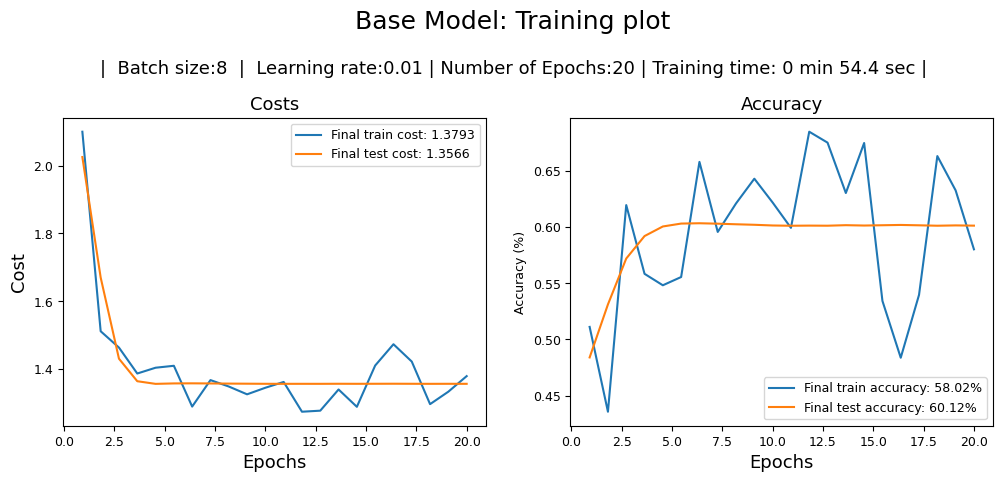

In [160]:
model_base.plot_loss_cost("Base Model: Training plot")

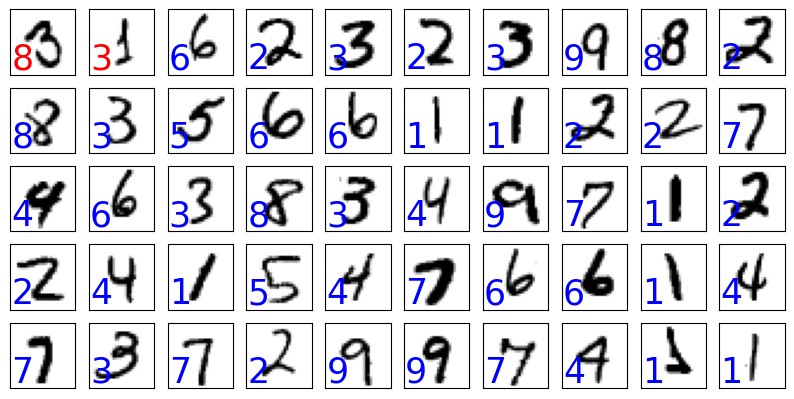

In [ ]:
model_base.plot_predictions(test_dataset, 50)

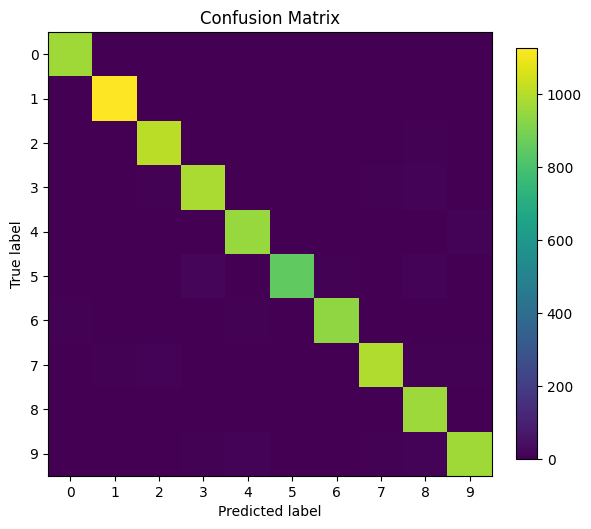

In [ ]:
model_base.plot_confusion_matrix(test_dataset)

In [ ]:

sum(p.numel() for p in model_base.model.parameters() if p.requires_grad)

344200